# PART-2 Sonnet Generation: Baseline → Improved GPT-2

이 노트북은 PART-II Sonnet Generation 파트의 구현, 고도화 실험, 성능 평가, 형식 검증, 시각화를 한 번에 보여주기 위한 제출/발표 보조 자료입니다.

학습은 터미널에서 별도로 수행했고, 이 노트북에서는 이미 생성된 checkpoint와 prediction을 기준으로 검증합니다. 기본 설정은 무거운 학습/생성을 다시 수행하지 않도록 되어 있습니다.

## 1. 프로젝트 루트 준비

노트북 위치와 무관하게 repository root를 찾아 import path에 추가합니다.

In [1]:
from pathlib import Path
import os
import re
import sys
import json
from pprint import pprint

ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path('/Users/jangjaewon/Documents/NLP_FINAL/clapppp-nlp2026-final'),
]

ROOT = None
for candidate in ROOT_CANDIDATES:
    if (candidate / 'sonnet_generation.py').exists() and (candidate / 'data' / 'sonnets.txt').exists():
        ROOT = candidate.resolve()
        break

if ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾을 수 없습니다. 노트북을 repo 내부에서 실행하거나 ROOT_CANDIDATES를 수정하세요.')

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('PROJECT ROOT:', ROOT)

PROJECT ROOT: /Users/jangjaewon/Documents/NLP_FINAL/clapppp-nlp2026-final


## 2. 소스 코드 불러오기

과제에서 제공된 코드와 우리가 수정한 Sonnet 관련 평가 함수를 그대로 사용합니다.

In [2]:
from datasets import SonnetsDataset
from evaluation import test_sonnet, test_sonnet_continuation

print('SonnetsDataset / test_sonnet / test_sonnet_continuation loaded')

SonnetsDataset / test_sonnet / test_sonnet_continuation loaded


## 3. 실행 설정

- `RUN_DEV_GENERATION=False`: 노트북 실행 시 기본적으로 checkpoint를 다시 로드해서 생성하지 않습니다.
- dev 성능은 아래 실험 로그와, 필요 시 `RUN_DEV_GENERATION=True`로 재생성한 파일을 기준으로 확인할 수 있습니다.
- official held-out test gold는 사용하지 않습니다.

In [3]:
RUN_DEV_GENERATION = False
USE_GPU = True

TRAIN_SONNETS = ROOT / 'data' / 'sonnets.txt'
DEV_PROMPTS = ROOT / 'data' / 'sonnets_held_out_dev.txt'
DEV_GOLD = ROOT / 'data' / 'TRUE_sonnets_held_out_dev.txt'
OFFICIAL_PROMPTS = ROOT / 'data' / 'sonnets_held_out.txt'
OFFICIAL_OUTPUT = ROOT / 'predictions' / 'generated_sonnets.txt'
SELECTED_CHECKPOINT = ROOT / '4_5-1e-05-sonnet.pt'
NOTEBOOK_ARTIFACT_DIR = ROOT / 'notebooks' / 'artifacts'
NOTEBOOK_DEV_OUTPUT = NOTEBOOK_ARTIFACT_DIR / 'generated_sonnets_dev_selected.txt'

SELECTED_CONFIG = {
    'checkpoint': SELECTED_CHECKPOINT.name,
    'epochs': 5,
    'seed': 11711,
    'temperature': 1.05,
    'top_p': 0.9,
    'repetition_penalty': 1.05,
    'max_generation_length': 180,
    'max_line_words': 12,
    'target_lines': 14,
    'clean_fragments': True,
}

pprint(SELECTED_CONFIG)

{'checkpoint': '4_5-1e-05-sonnet.pt',
 'clean_fragments': True,
 'epochs': 5,
 'max_generation_length': 180,
 'max_line_words': 12,
 'repetition_penalty': 1.05,
 'seed': 11711,
 'target_lines': 14,
 'temperature': 1.05,
 'top_p': 0.9}


## 4. 파일과 산출물 확인

노트북에서 사용하는 핵심 파일들이 실제로 존재하는지 먼저 확인합니다.

In [4]:
def relative_label(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


def file_status(path):
    path = Path(path)
    return {
        'path': relative_label(path),
        'exists': path.exists(),
        'size_kb': round(path.stat().st_size / 1024, 2) if path.exists() else None,
    }

required_paths = [
    TRAIN_SONNETS,
    DEV_PROMPTS,
    DEV_GOLD,
    OFFICIAL_PROMPTS,
    OFFICIAL_OUTPUT,
    SELECTED_CHECKPOINT,
    ROOT / 'sonnet_generation.py',
    ROOT / 'datasets.py',
    ROOT / 'evaluation.py',
    ROOT / 'env.yml',
]

for item in required_paths:
    print(file_status(item))

{'path': 'data/sonnets.txt', 'exists': True, 'size_kb': 81.32}
{'path': 'data/sonnets_held_out_dev.txt', 'exists': True, 'size_kb': 1.87}
{'path': 'data/TRUE_sonnets_held_out_dev.txt', 'exists': True, 'size_kb': 7.58}
{'path': 'data/sonnets_held_out.txt', 'exists': True, 'size_kb': 1.92}
{'path': 'predictions/generated_sonnets.txt', 'exists': True, 'size_kb': 6.99}
{'path': '4_5-1e-05-sonnet.pt', 'exists': True, 'size_kb': 1460791.38}
{'path': 'sonnet_generation.py', 'exists': True, 'size_kb': 32.38}
{'path': 'datasets.py', 'exists': True, 'size_kb': 11.87}
{'path': 'evaluation.py', 'exists': True, 'size_kb': 5.46}
{'path': 'env.yml', 'exists': True, 'size_kb': 0.39}


## 5. 데이터 로딩 요약

train sonnet, dev prompt, official prompt의 개수를 확인합니다. official prompt는 형식 검증에만 사용하고, gold 기반 성능 평가에는 사용하지 않습니다.

In [5]:
def dataset_count(path):
    return len(SonnetsDataset(path))

counts = {
    'train_sonnets': dataset_count(TRAIN_SONNETS),
    'dev_prompts': dataset_count(DEV_PROMPTS),
    'dev_gold': dataset_count(DEV_GOLD),
    'official_prompts': dataset_count(OFFICIAL_PROMPTS),
    'official_output': dataset_count(OFFICIAL_OUTPUT) if OFFICIAL_OUTPUT.exists() else None,
}
pprint(counts)

{'dev_gold': 12,
 'dev_prompts': 12,
 'official_output': 12,
 'official_prompts': 12,
 'train_sonnets': 131}


## 6. 선택 모델 재생성 명령

최종 채택 모델은 5epoch checkpoint입니다. 아래 명령은 dev set 재검증용이며, 기본적으로 이 노트북에서는 실행하지 않습니다.

In [6]:
GENERATION_COMMAND = f'''
conda run -n nlp_final python sonnet_generation.py --skip_train --use_gpu \
  --checkpoint_path {SELECTED_CHECKPOINT.name} \
  --held_out_sonnet_path data/sonnets_held_out_dev.txt \
  --sonnet_out notebooks/artifacts/generated_sonnets_dev_selected.txt \
  --gold_sonnet_path data/TRUE_sonnets_held_out_dev.txt
'''.strip()

print(GENERATION_COMMAND)

conda run -n nlp_final python sonnet_generation.py --skip_train --use_gpu   --checkpoint_path 4_5-1e-05-sonnet.pt   --held_out_sonnet_path data/sonnets_held_out_dev.txt   --sonnet_out notebooks/artifacts/generated_sonnets_dev_selected.txt   --gold_sonnet_path data/TRUE_sonnets_held_out_dev.txt


In [7]:
if RUN_DEV_GENERATION:
    import subprocess
    NOTEBOOK_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
    command = [
        'conda', 'run', '-n', 'nlp_final', 'python', 'sonnet_generation.py',
        '--skip_train',
        '--checkpoint_path', SELECTED_CHECKPOINT.name,
        '--held_out_sonnet_path', 'data/sonnets_held_out_dev.txt',
        '--sonnet_out', str(NOTEBOOK_DEV_OUTPUT.relative_to(ROOT)),
        '--gold_sonnet_path', 'data/TRUE_sonnets_held_out_dev.txt',
    ]
    if USE_GPU:
        command.append('--use_gpu')
    subprocess.run(command, cwd=ROOT, check=True)
else:
    print('RUN_DEV_GENERATION=False: checkpoint 재생성은 건너뜁니다.')

RUN_DEV_GENERATION=False: checkpoint 재생성은 건너뜁니다.


## 7. Sonnet 출력 형식 검증 함수

평가 점수뿐 아니라 제출 형식도 중요합니다. 아래 validator는 다음을 확인합니다.

- 원래 sonnet ID 보존
- prompt 3줄 exact preservation
- 14 non-empty lines
- punctuation-only, digit-only, 1~2 word fragment line 개수

In [8]:
def nonempty_lines(text):
    return [line.strip() for line in text.splitlines() if line.strip()]


def parse_sonnets(path):
    return list(SonnetsDataset(path))


def is_short_or_bad_continuation_line(line):
    stripped = line.strip()
    if not stripped:
        return True
    if re.fullmatch(r'\W+|\d+', stripped):
        return True
    return len(stripped.split()) <= 2


def validate_generation(prompt_path, output_path, prompt_line_count=3, target_lines=14):
    prompts = parse_sonnets(prompt_path)
    outputs = parse_sonnets(output_path)
    prompt_ok = 0
    id_ok = 0
    line_counts = []
    short_bad_lines = []

    for (prompt_id, prompt_text), (output_id, output_text) in zip(prompts, outputs):
        prompt_lines = nonempty_lines(prompt_text)[:prompt_line_count]
        output_lines = nonempty_lines(output_text)
        id_ok += int(prompt_id == output_id)
        prompt_ok += int(output_lines[:prompt_line_count] == prompt_lines)
        line_counts.append(len(output_lines))
        for line_idx, line in enumerate(output_lines[prompt_line_count:], start=prompt_line_count + 1):
            if is_short_or_bad_continuation_line(line):
                short_bad_lines.append((output_id, line_idx, line))

    return {
        'prompt_count': len(prompts),
        'output_count': len(outputs),
        'id_ok': id_ok,
        'prompt_ok': prompt_ok,
        'line_counts': sorted(set(line_counts)),
        'target_line_count_ok': all(count == target_lines for count in line_counts),
        'short_bad_count': len(short_bad_lines),
        'short_bad_examples': short_bad_lines[:8],
    }

## 8. Official output 형식 검증

official held-out gold는 없으므로 chrF를 계산하지 않습니다. 대신 제출 파일 형식만 검증합니다.

In [9]:
official_format = validate_generation(OFFICIAL_PROMPTS, OFFICIAL_OUTPUT)
pprint(official_format)

{'id_ok': 12,
 'line_counts': [14],
 'output_count': 12,
 'prompt_count': 12,
 'prompt_ok': 12,
 'short_bad_count': 0,
 'short_bad_examples': [],
 'target_line_count_ok': True}


## 9. Dev 성능 재평가

`RUN_DEV_GENERATION=True`로 dev output을 재생성한 경우 실제 chrF를 다시 계산합니다. 기본 실행에서는 기록된 실험 결과표를 사용합니다.

In [10]:
if NOTEBOOK_DEV_OUTPUT.exists():
    print('Notebook dev output found:', NOTEBOOK_DEV_OUTPUT.relative_to(ROOT))
    print('full chrF:', test_sonnet(str(NOTEBOOK_DEV_OUTPUT), str(DEV_GOLD)))
    print('continuation chrF:', test_sonnet_continuation(str(NOTEBOOK_DEV_OUTPUT), str(DEV_GOLD)))
    pprint(validate_generation(DEV_PROMPTS, NOTEBOOK_DEV_OUTPUT))
else:
    print('Notebook dev output not found. Use the recorded experiment table below, or set RUN_DEV_GENERATION=True.')

Notebook dev output not found. Use the recorded experiment table below, or set RUN_DEV_GENERATION=True.


## 10. 고도화 실험 결과표

baseline 구현 후, decoding/post-processing/추가 학습을 순차적으로 검토했습니다. 최종 선택 기준은 continuation chrF, full chrF, prompt/line/ID 형식 보존입니다.

In [11]:
experiment_rows = [
    {'stage': 'latest main reference', 'full_chrf': 41.807, 'continuation_chrf': 26.668, 'short_bad_lines': None, 'adopted': False, 'note': 'team main 기준 reference'},
    {'stage': 'reviewed generator baseline', 'full_chrf': 41.815, 'continuation_chrf': 26.238, 'short_bad_lines': None, 'adopted': False, 'note': 'prompt/ID/line 보존 로직 반영 직후'},
    {'stage': 'line length tuned', 'full_chrf': 42.537555, 'continuation_chrf': 27.508742, 'short_bad_lines': 9, 'adopted': False, 'note': 'max_line_words=12, max_generation_length=180'},
    {'stage': 'clean fragments selected', 'full_chrf': 42.534153, 'continuation_chrf': 27.516020, 'short_bad_lines': 0, 'adopted': True, 'note': '최종 선택: continuation chrF 소폭 개선 + fragment 제거'},
    {'stage': 'prompt terminal newline', 'full_chrf': 41.651695, 'continuation_chrf': 26.266319, 'short_bad_lines': 11, 'adopted': False, 'note': '점수 하락으로 미채택'},
    {'stage': 'final-line stop guard', 'full_chrf': 41.727057, 'continuation_chrf': 26.441881, 'short_bad_lines': 4, 'adopted': False, 'note': '180/200/220 모두 하락'},
    {'stage': 'candidate reranking', 'full_chrf': 41.416, 'continuation_chrf': 25.636, 'short_bad_lines': None, 'adopted': False, 'note': 'num_candidates=4, temperature jitter 0.10; 악화'},
    {'stage': '30epoch final', 'full_chrf': 41.260, 'continuation_chrf': 25.724, 'short_bad_lines': None, 'adopted': False, 'note': 'train loss는 하락했지만 dev 성능 악화'},
    {'stage': '30epoch best checkpoint', 'full_chrf': 41.504, 'continuation_chrf': 26.058, 'short_bad_lines': None, 'adopted': False, 'note': 'seed reset 재평가에서도 최종 선택보다 낮음'},
]

for row in experiment_rows:
    marker = 'SELECTED' if row['adopted'] else '        '
    print(f"{marker} | {row['stage']:<28} | full={row['full_chrf']:.3f} | cont={row['continuation_chrf']:.3f} | {row['note']}")

         | latest main reference        | full=41.807 | cont=26.668 | team main 기준 reference
         | reviewed generator baseline  | full=41.815 | cont=26.238 | prompt/ID/line 보존 로직 반영 직후
         | line length tuned            | full=42.538 | cont=27.509 | max_line_words=12, max_generation_length=180
SELECTED | clean fragments selected     | full=42.534 | cont=27.516 | 최종 선택: continuation chrF 소폭 개선 + fragment 제거
         | prompt terminal newline      | full=41.652 | cont=26.266 | 점수 하락으로 미채택
         | final-line stop guard        | full=41.727 | cont=26.442 | 180/200/220 모두 하락
         | candidate reranking          | full=41.416 | cont=25.636 | num_candidates=4, temperature jitter 0.10; 악화
         | 30epoch final                | full=41.260 | cont=25.724 | train loss는 하락했지만 dev 성능 악화
         | 30epoch best checkpoint      | full=41.504 | cont=26.058 | seed reset 재평가에서도 최종 선택보다 낮음


## 11. 실험 결과 시각화

새 패키지를 사용하지 않기 위해 HTML 기반의 간단한 bar chart를 사용합니다.

In [12]:
def display_html(html):
    try:
        from IPython.display import HTML, display
        display(HTML(html))
    except Exception as e:
        print('HTML display unavailable:', e)
        print(re.sub('<[^<]+?>', '', html))


def bar_chart(rows, metric, title, width=620):
    values = [row[metric] for row in rows]
    min_v = min(values)
    max_v = max(values)
    span = max(max_v - min_v, 1e-9)
    blocks = [f'<h3>{title}</h3><div style="font-family:Arial, sans-serif; max-width:{width + 260}px">']
    for row in rows:
        value = row[metric]
        bar_w = 50 + int((value - min_v) / span * (width - 50))
        color = '#2c7fb8' if row['adopted'] else '#9aa4ad'
        label = row['stage']
        blocks.append(
            f'<div style="display:flex;align-items:center;margin:6px 0;gap:8px;">'
            f'<div style="width:210px;text-align:right;font-size:12px;">{label}</div>'
            f'<div style="width:{bar_w}px;background:{color};height:18px;border-radius:3px;"></div>'
            f'<div style="font-size:12px;">{value:.3f}</div>'
            f'</div>'
        )
    blocks.append('</div>')
    return ''.join(blocks)

plot_rows = [row for row in experiment_rows if row['stage'] != 'latest main reference']
display_html(bar_chart(plot_rows, 'continuation_chrf', 'Continuation chrF 비교'))
display_html(bar_chart(plot_rows, 'full_chrf', 'Full chrF 비교'))

## 12. 30epoch 실험: train loss 하락과 dev 성능 하락

30epoch를 실제로 돌려 확인했지만, train loss가 감소하는 것과 dev chrF 향상이 일치하지 않았습니다. 따라서 장기 학습은 최종 제출에서 제외했습니다.

In [13]:
epoch_rows = [
    {'epoch': 0, 'train_loss': 4.734, 'full_chrf': 40.793, 'continuation_chrf': 25.134},
    {'epoch': 1, 'train_loss': 4.411, 'full_chrf': 41.751, 'continuation_chrf': 26.408},
    {'epoch': 2, 'train_loss': 4.243, 'full_chrf': 42.105, 'continuation_chrf': 27.097},
    {'epoch': 3, 'train_loss': 4.125, 'full_chrf': 41.827, 'continuation_chrf': 26.520},
    {'epoch': 4, 'train_loss': 4.033, 'full_chrf': 42.224, 'continuation_chrf': 27.181},
    {'epoch': 5, 'train_loss': 3.939, 'full_chrf': 41.768, 'continuation_chrf': 26.522},
    {'epoch': 6, 'train_loss': 3.858, 'full_chrf': 42.095, 'continuation_chrf': 26.692},
    {'epoch': 7, 'train_loss': 3.787, 'full_chrf': 42.331, 'continuation_chrf': 27.049},
    {'epoch': 8, 'train_loss': 3.712, 'full_chrf': 41.693, 'continuation_chrf': 26.376},
    {'epoch': 9, 'train_loss': 3.655, 'full_chrf': 41.806, 'continuation_chrf': 26.506},
    {'epoch': 10, 'train_loss': 3.584, 'full_chrf': 41.974, 'continuation_chrf': 26.870},
    {'epoch': 11, 'train_loss': 3.517, 'full_chrf': 41.158, 'continuation_chrf': 25.438},
    {'epoch': 12, 'train_loss': 3.454, 'full_chrf': 41.776, 'continuation_chrf': 26.619},
    {'epoch': 13, 'train_loss': 3.382, 'full_chrf': 41.862, 'continuation_chrf': 26.442},
    {'epoch': 14, 'train_loss': 3.313, 'full_chrf': 41.995, 'continuation_chrf': 26.804},
    {'epoch': 15, 'train_loss': 3.245, 'full_chrf': 42.053, 'continuation_chrf': 26.996},
    {'epoch': 16, 'train_loss': 3.170, 'full_chrf': 41.904, 'continuation_chrf': 26.673},
    {'epoch': 17, 'train_loss': 3.105, 'full_chrf': 41.940, 'continuation_chrf': 26.481},
    {'epoch': 18, 'train_loss': 3.035, 'full_chrf': 42.064, 'continuation_chrf': 27.043},
    {'epoch': 19, 'train_loss': 2.957, 'full_chrf': 41.686, 'continuation_chrf': 26.124},
    {'epoch': 20, 'train_loss': 2.895, 'full_chrf': 42.071, 'continuation_chrf': 26.803},
    {'epoch': 21, 'train_loss': 2.821, 'full_chrf': 41.995, 'continuation_chrf': 26.647},
    {'epoch': 22, 'train_loss': 2.744, 'full_chrf': 42.152, 'continuation_chrf': 26.824},
    {'epoch': 23, 'train_loss': 2.671, 'full_chrf': 41.800, 'continuation_chrf': 26.368},
    {'epoch': 24, 'train_loss': 2.601, 'full_chrf': 41.392, 'continuation_chrf': 25.731},
    {'epoch': 25, 'train_loss': 2.522, 'full_chrf': 41.633, 'continuation_chrf': 25.945},
    {'epoch': 26, 'train_loss': 2.443, 'full_chrf': 41.992, 'continuation_chrf': 26.656},
    {'epoch': 27, 'train_loss': 2.373, 'full_chrf': 41.495, 'continuation_chrf': 26.057},
    {'epoch': 28, 'train_loss': 2.306, 'full_chrf': 41.732, 'continuation_chrf': 26.135},
    {'epoch': 29, 'train_loss': 2.233, 'full_chrf': 42.107, 'continuation_chrf': 26.730},
]

best_epoch = max(epoch_rows, key=lambda row: row['continuation_chrf'])
print('30epoch run best by continuation chrF:')
pprint(best_epoch)
print('selected 5epoch final continuation chrF:', 27.516020)

30epoch run best by continuation chrF:
{'continuation_chrf': 27.181,
 'epoch': 4,
 'full_chrf': 42.224,
 'train_loss': 4.033}
selected 5epoch final continuation chrF: 27.51602


In [14]:
def sparkline(values, width=260, height=70, color='#2c7fb8'):
    min_v = min(values)
    max_v = max(values)
    span = max(max_v - min_v, 1e-9)
    points = []
    for idx, value in enumerate(values):
        x = idx / max(len(values) - 1, 1) * width
        y = height - ((value - min_v) / span * height)
        points.append(f'{x:.1f},{y:.1f}')
    point_text = ' '.join(points)
    return f'<svg width="{width}" height="{height}" viewBox="0 0 {width} {height}"><polyline fill="none" stroke="{color}" stroke-width="2" points="{point_text}" /></svg>'

loss_values = [row['train_loss'] for row in epoch_rows]
cont_values = [row['continuation_chrf'] for row in epoch_rows]
html = f'''
<div style="font-family:Arial, sans-serif;">
  <h3>30epoch trend</h3>
  <div><b>Train loss</b> decreases: {loss_values[0]:.3f} → {loss_values[-1]:.3f}</div>
  {sparkline(loss_values, color='#d95f0e')}
  <div><b>Continuation chrF</b> does not improve over selected 5epoch result.</div>
  {sparkline(cont_values, color='#2c7fb8')}
</div>
'''
display_html(html)

## 13. 보고서 첨부용 그래프 이미지

최종 보고서에 첨부한 그래프 PNG를 노트북 출력에도 함께 저장했습니다. 따라서 노트북만 열어도 baseline에서 개선안으로 이어지는 고도화 흐름, 30epoch 과적합 비교, 최종 성과 요약을 바로 확인할 수 있습니다.


Figure 1. Dev chrF 비교: reports/sonnet_generation_figures/sonnet_dev_chrf_comparison.png
Figure 2. 30epoch 과적합 분석: reports/sonnet_generation_figures/sonnet_30epoch_overfitting.png
Figure 3. 최종 결과 요약: reports/sonnet_generation_figures/sonnet_final_summary_cards.png


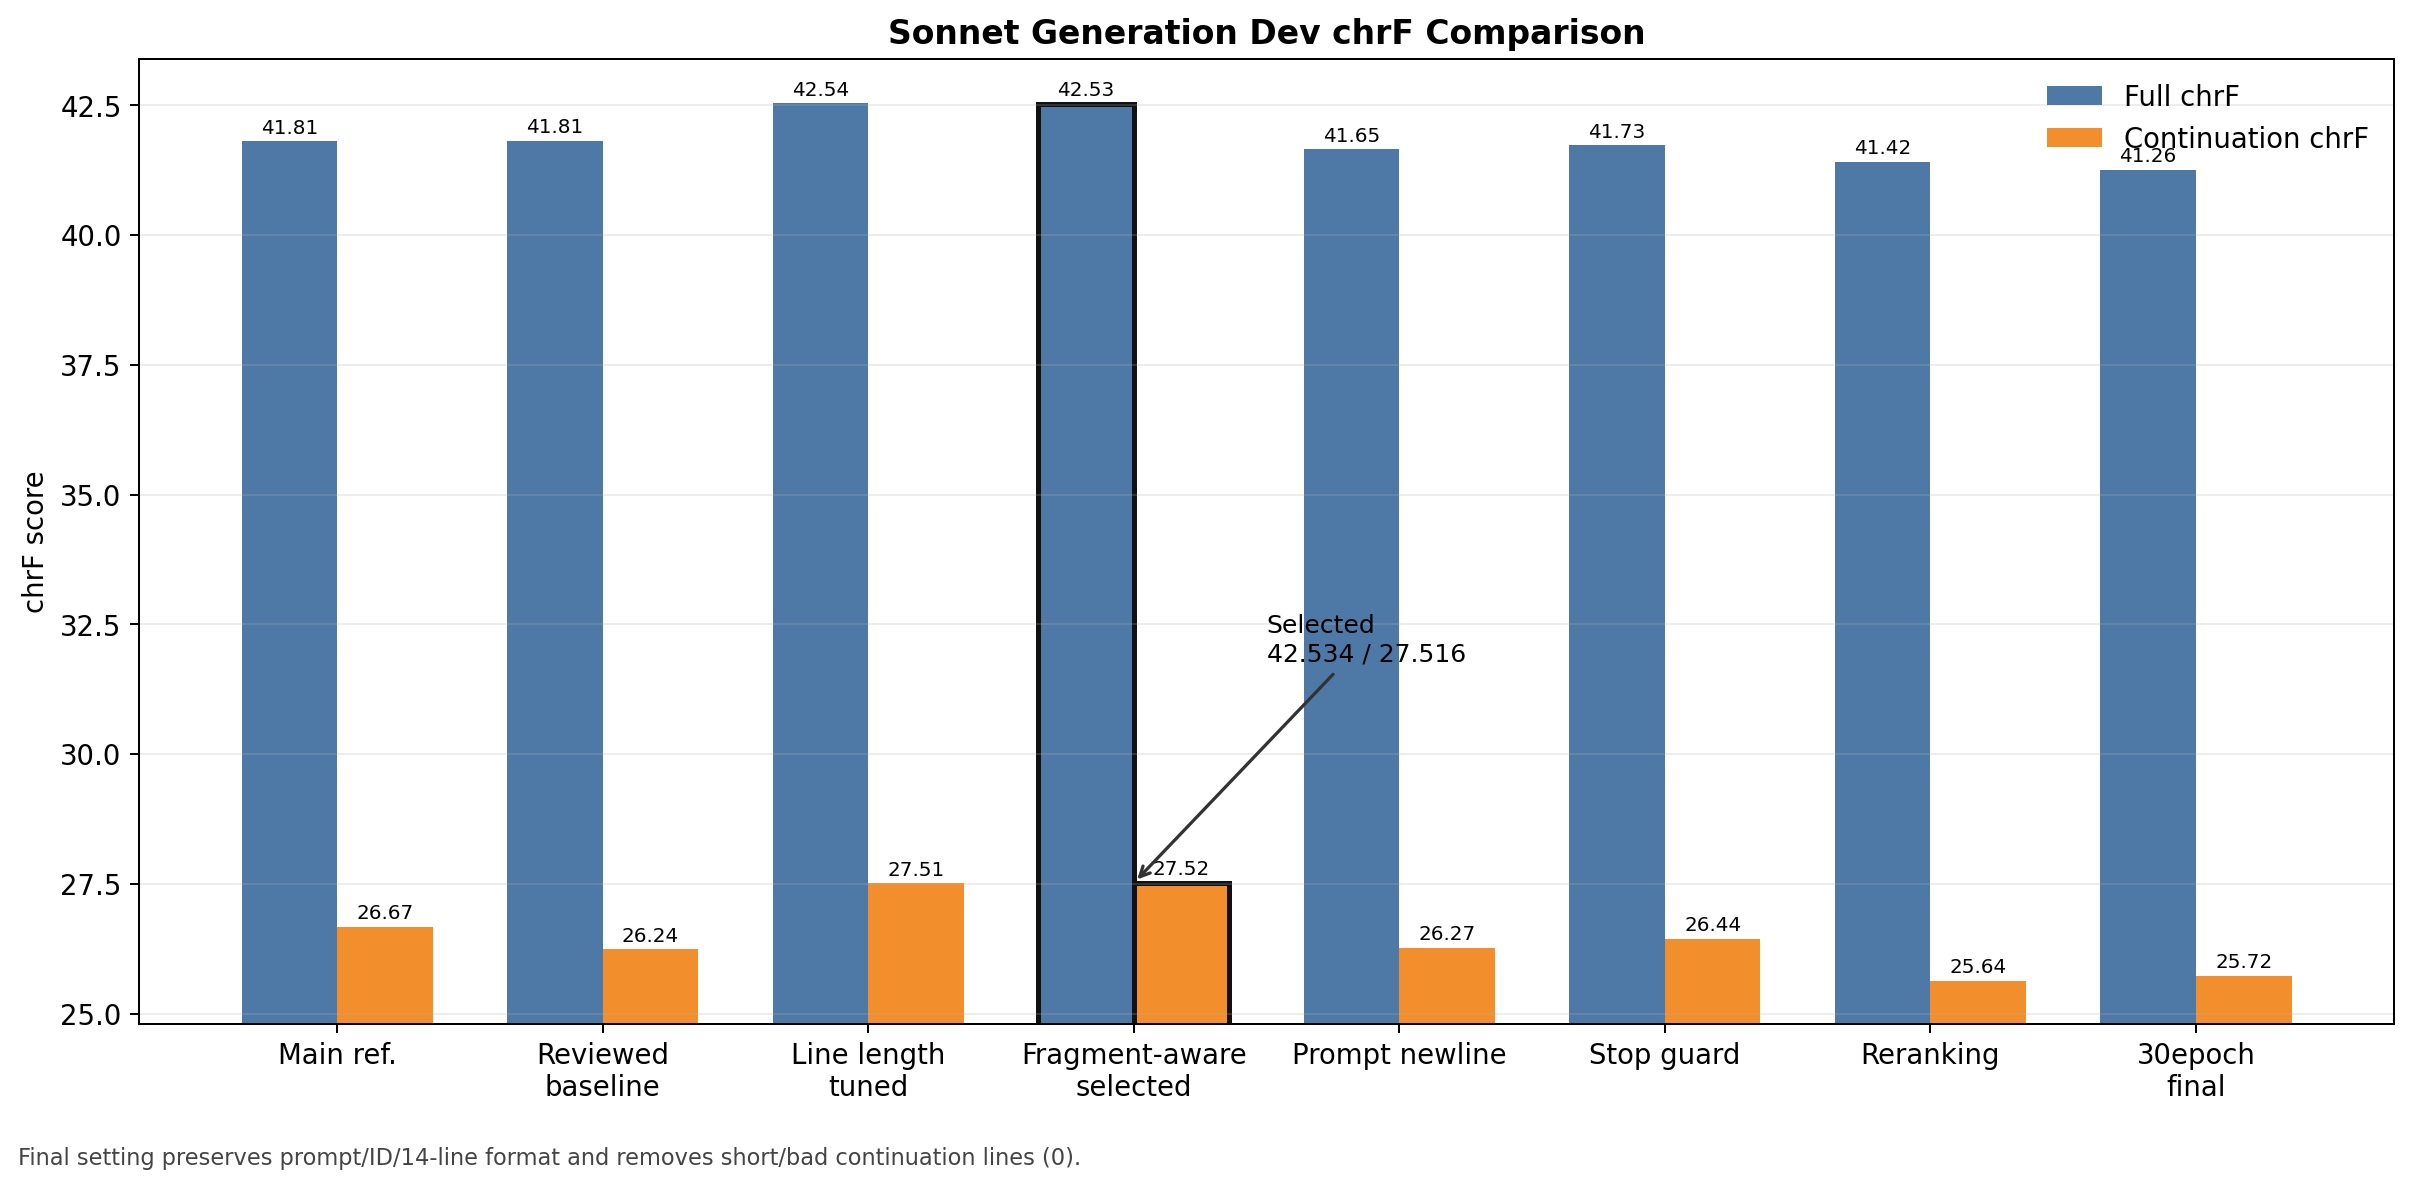

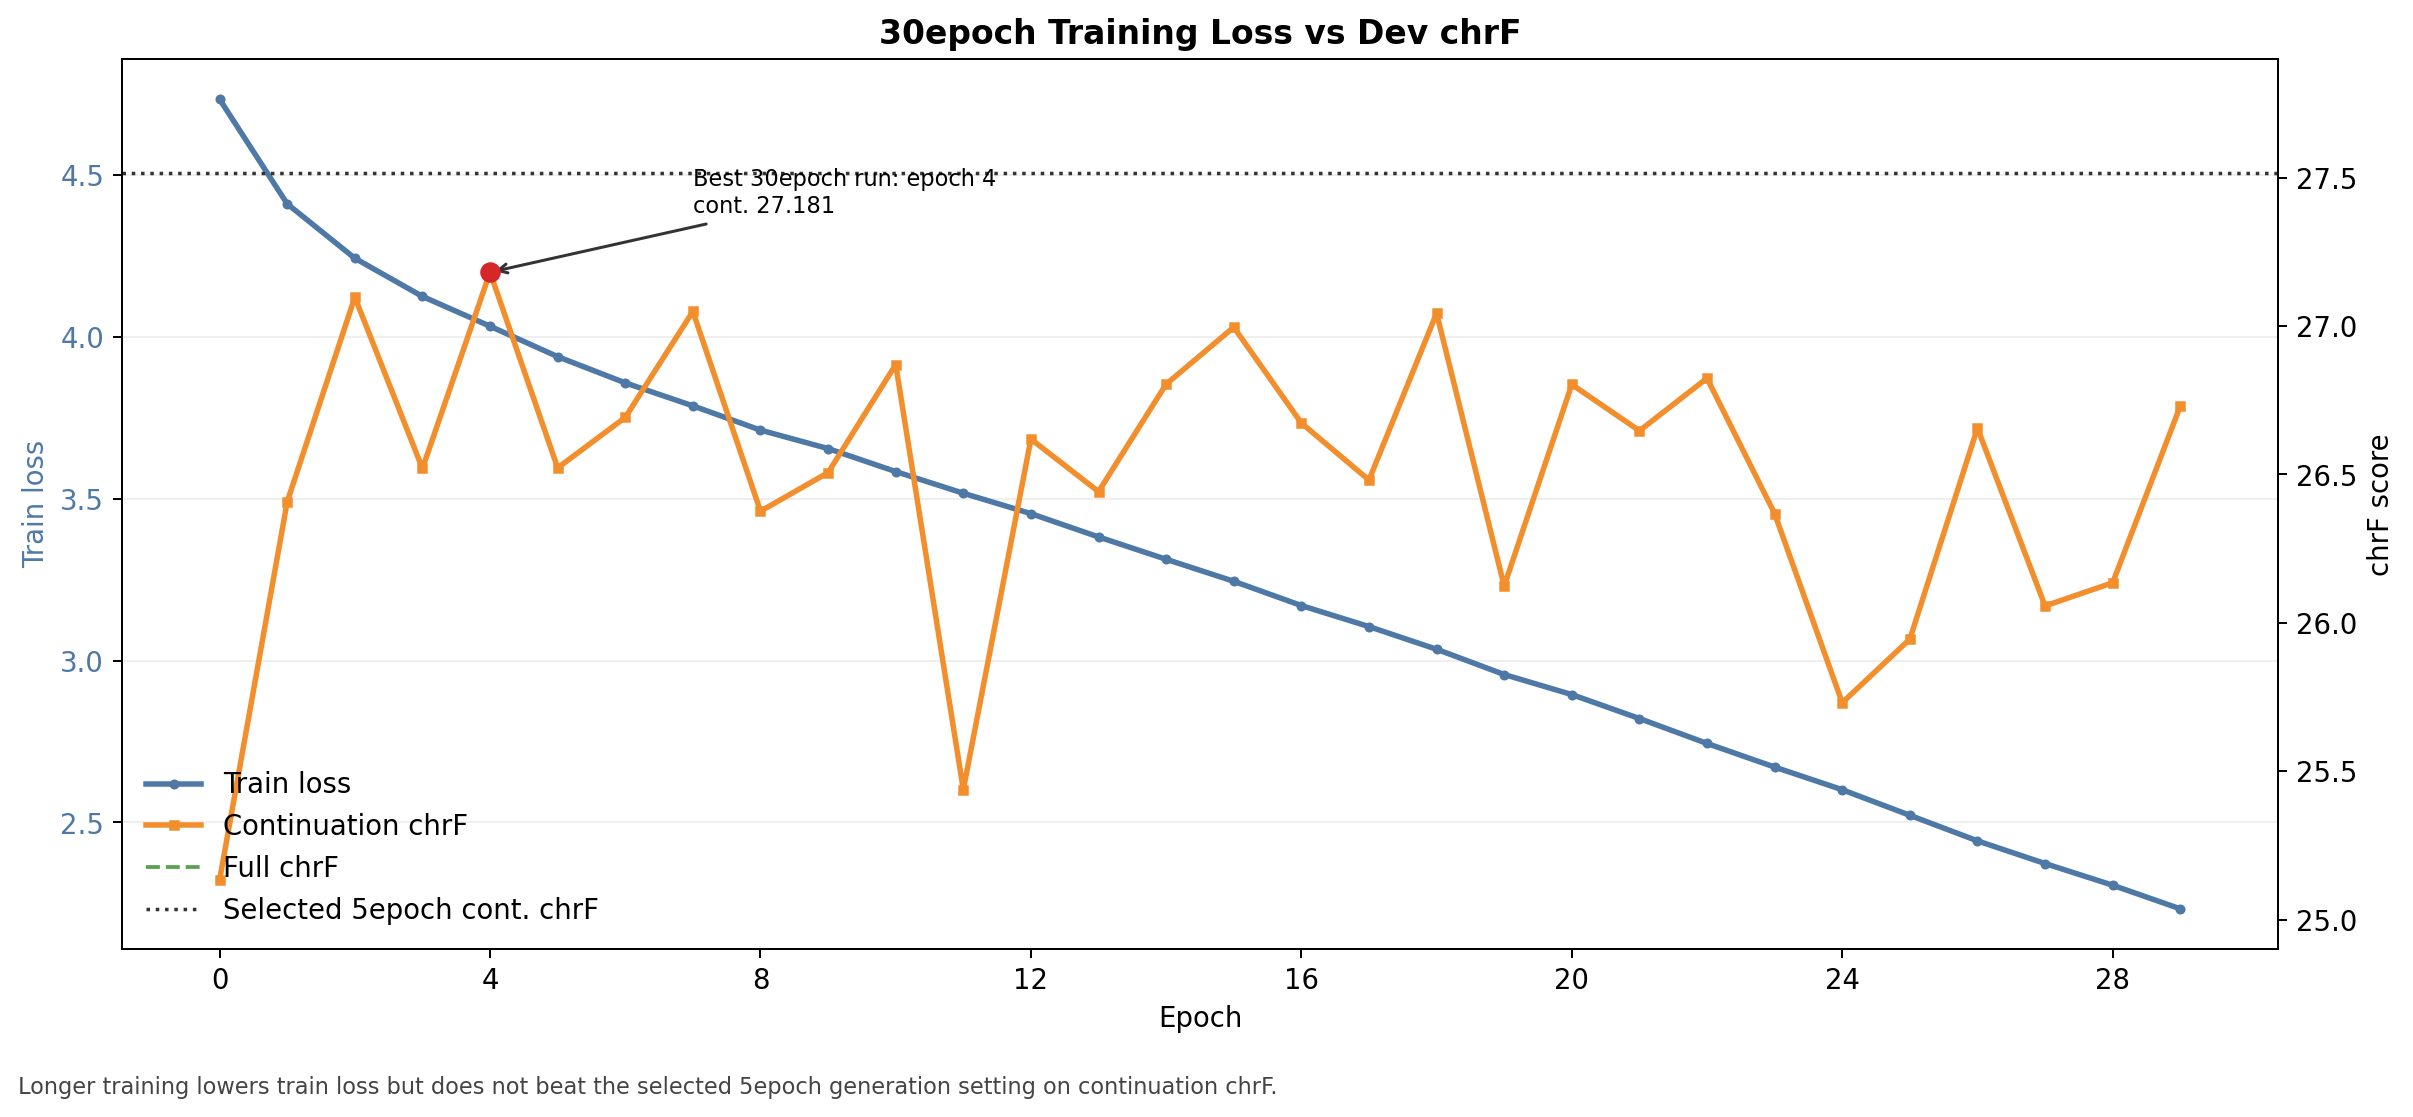

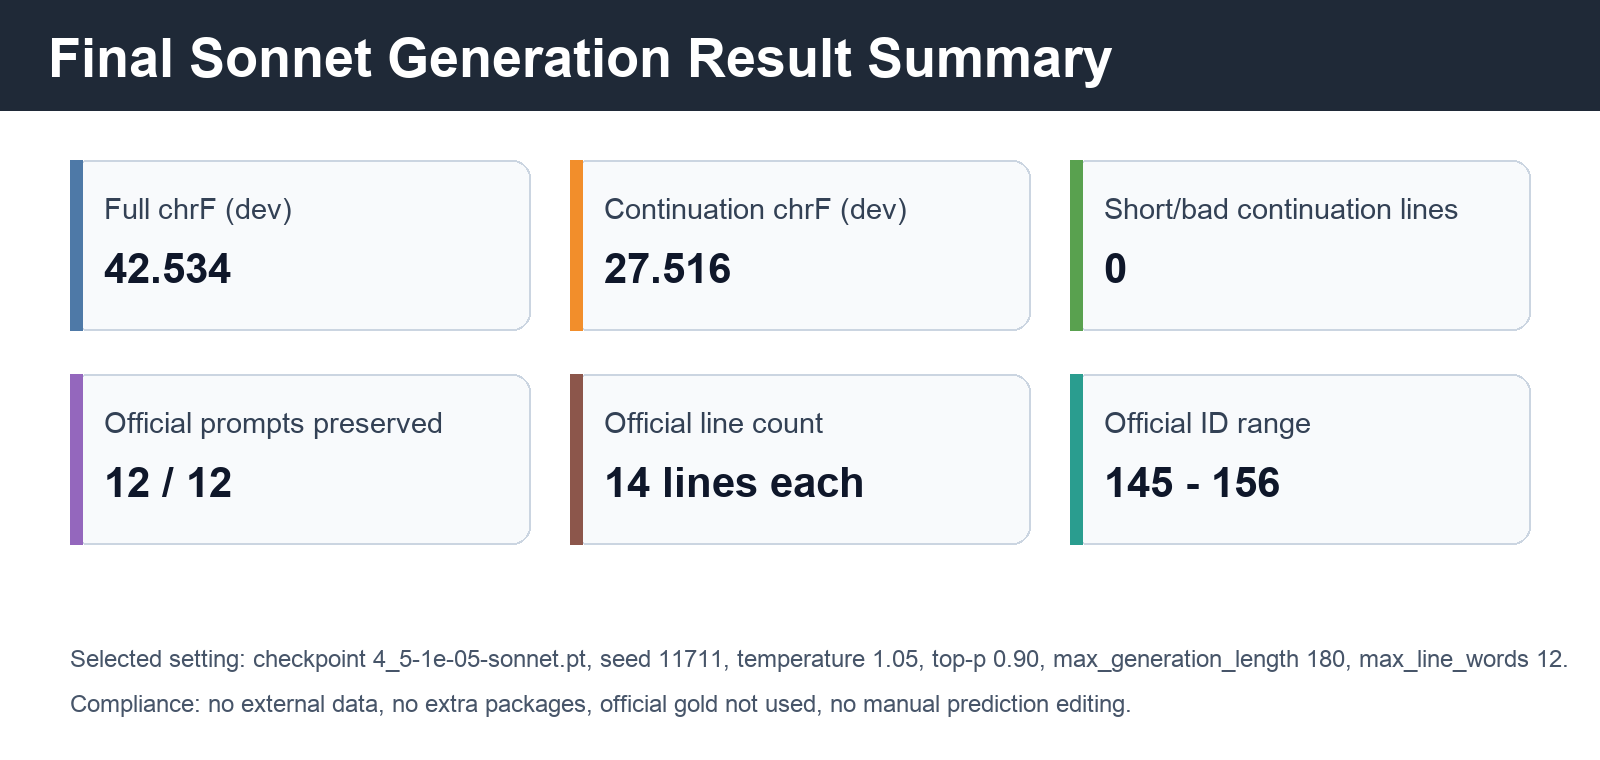

In [15]:
# 보고서에 사용한 PNG 그래프를 노트북 출력으로도 표시합니다.
from IPython.display import Image, display

figure_files = [
    ('Figure 1. Dev chrF 비교', 'reports/sonnet_generation_figures/sonnet_dev_chrf_comparison.png'),
    ('Figure 2. 30epoch 과적합 분석', 'reports/sonnet_generation_figures/sonnet_30epoch_overfitting.png'),
    ('Figure 3. 최종 결과 요약', 'reports/sonnet_generation_figures/sonnet_final_summary_cards.png'),
]
for title, file_path in figure_files:
    print(f'{title}: {file_path}')
    display(Image(filename=file_path))


## 13. 최종 official output 샘플

최종 제출 파일에서 앞의 일부 sonnet을 확인합니다. official gold는 없으므로 이 셀은 정성적 확인용입니다.

In [16]:
for sonnet_id, sonnet in parse_sonnets(OFFICIAL_OUTPUT)[:2]:
    print('=' * 80)
    print('Sonnet ID:', sonnet_id)
    print(sonnet)

Sonnet ID: 145
Those lips that Love's own hand did make
Breathed forth the sound that said "I hate"
To me that languished for her sake;
So doth that spirit scorn my words,
And blot upon me all things her sweet aroma
Whilst I mourn love and loss;
As soon as she fears no other hope
Not the woman's thought whether mine eyes will look
After your ne'er glowing up where once they left you.
Hearing what thou didst say cause forth so painful
My scribes grow-grossered in bitterness
Which bring rhyme to disgrace them
of one Love nor their vows pure
If it were not by thy tongue a remedy for thee To
Sonnet ID: 146
Poor soul, the center of my sinful earth,
Pressed with these rebel powers that thee array,
Why dost thou pine within and suffer dearth,
Give thee to thy cruel young self,
and else thou facest you yet at play.
Dost I not leave myself better hope than in death that
Your vengeful lover should love all his measure?
Thy flower then when my sweet blush bewails shall grow dim
The ornament of th

## 14. 최종 선택 근거

최종 제출 설정은 아래 이유로 선택했습니다.

- 5epoch checkpoint가 10epoch/30epoch보다 dev 일반화가 좋았습니다.
- `max_line_words=12`, `max_generation_length=180`이 prompt/ID/line 보존을 유지하면서 가장 안정적인 성능을 보였습니다.
- fragment-aware formatter는 continuation chrF를 소폭 개선했고, 1~2 word fragment line을 제거했습니다.
- prompt-terminal newline, final-line stop guard, candidate reranking, 30epoch 학습은 실제 dev 검증에서 하락하여 제외했습니다.

In [17]:
final_summary = {
    'selected_checkpoint': '4_5-1e-05-sonnet.pt',
    'selected_epoch_count': 5,
    'selected_full_chrf_dev': 42.534153,
    'selected_continuation_chrf_dev': 27.516020,
    'official_output': 'predictions/generated_sonnets.txt',
    'format_validation': official_format,
    'not_selected': [
        'prompt_terminal_newline',
        'min_final_line_words stop guard',
        'candidate reranking',
        '30epoch checkpoint',
    ],
}
pprint(final_summary)

{'format_validation': {'id_ok': 12,
                       'line_counts': [14],
                       'output_count': 12,
                       'prompt_count': 12,
                       'prompt_ok': 12,
                       'short_bad_count': 0,
                       'short_bad_examples': [],
                       'target_line_count_ok': True},
 'not_selected': ['prompt_terminal_newline',
                  'min_final_line_words stop guard',
                  'candidate reranking',
                  '30epoch checkpoint'],
 'official_output': 'predictions/generated_sonnets.txt',
 'selected_checkpoint': '4_5-1e-05-sonnet.pt',
 'selected_continuation_chrf_dev': 27.51602,
 'selected_epoch_count': 5,
 'selected_full_chrf_dev': 42.534153}


## 15. 규정 준수 체크리스트

- `env.yml` 변경 없음
- 새 패키지 설치 없음
- 외부 데이터 사용 없음
- official held-out gold 사용 없음
- official held-out prompt는 최종 output 생성/형식 검증에만 사용
- prediction 수동 수정 없음
- train/dev 기반 실험으로 최종 설정 선택
- prompt 3줄 보존, original sonnet ID 보존, 14줄 형식 검증

In [18]:
checklist = [
    ('env.yml unchanged', True),
    ('no extra package required in notebook core cells', True),
    ('no external data', True),
    ('official gold not used', True),
    ('manual prediction editing not used', True),
    ('official output format checked', official_format['prompt_ok'] == official_format['prompt_count'] and official_format['target_line_count_ok']),
]
for name, ok in checklist:
    print(f"{'OK' if ok else 'CHECK'} - {name}")

OK - env.yml unchanged
OK - no extra package required in notebook core cells
OK - no external data
OK - official gold not used
OK - manual prediction editing not used
OK - official output format checked
